In [8]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
# import matplotlib.pylab as plt
import matplotlib.font_manager as fm
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac (AppleGothic 또는 AppleSDGothicNeo)
# plt.rcParams['font.family'] = 'NanumGothic' # Linux (NanumGothic 또는 다른 설치된 한글 폰트)

plt.rcParams['axes.unicode_minus'] = False #glypy 8722: Axes에 - 표시 안되는 것
# plt.title('한글 타이틀...')

In [1]:
from sklearn.datasets import load_digits
digits = load_digits()

In [2]:
print(digits['DESCR'])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [3]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [4]:
digits['target_names']

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

### 이미지 보기

In [5]:
digits.data[0].shape

(64,)

In [6]:
digits.images[0].shape

(8, 8)

In [7]:
digits.data[0].reshape(8,8).shape

(8, 8)

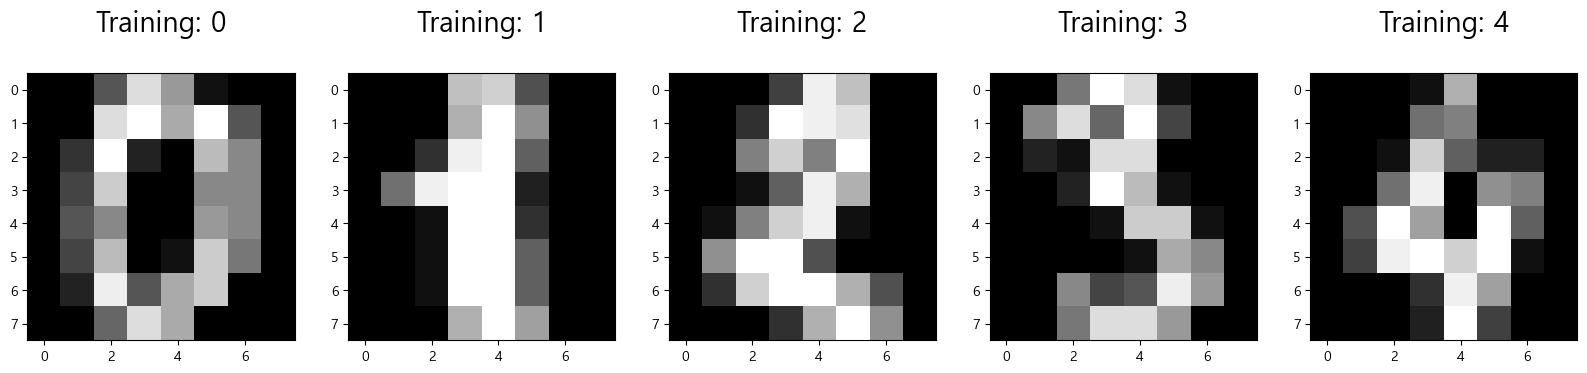

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))

for i, (image, label) in enumerate( zip(digits['data'][0:5],digits['target'][0:5])):
    plt.subplot(1, 5, i+1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title('Training: %i\n' % label, fontsize=20)

# SVM

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=.3, random_state=50)

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, r2_score, classification_report

In [15]:
model = SVC(kernel='linear', random_state=50)
print('모델 훈련 중')
model.fit(X_train, y_train)
print('훈련 완료')

모델 훈련 중
훈련 완료


In [16]:
pred_test = model.predict(X_test)

In [17]:
accuracy_score(y_test, pred_test)

0.9685185185185186

In [19]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        63
           1       0.94      0.98      0.96        59
           2       1.00      1.00      1.00        55
           3       0.96      0.96      0.96        45
           4       0.98      1.00      0.99        55
           5       1.00      0.91      0.95        54
           6       0.98      1.00      0.99        53
           7       0.98      0.98      0.98        53
           8       0.93      0.89      0.91        47
           9       0.92      0.96      0.94        56

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



In [20]:
pred_test != y_test

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [22]:
# 예측이 틀린 경우
np.where(pred_test != y_test)

(array([ 18,  58,  61, 159, 192, 268, 284, 290, 328, 336, 401, 409, 427,
        465, 489, 509, 532]),)

In [23]:
digits.target[532]

np.int64(6)

In [38]:
# 예측이 틀린 경우만 찾기
incorrect_indices = np.where(pred_test != y_test)

In [39]:
incorrect_indices[:10][0]

array([ 18,  58,  61, 159, 192, 268, 284, 290, 328, 336, 401, 409, 427,
       465, 489, 509, 532])


1개의 오분류된 샘플:


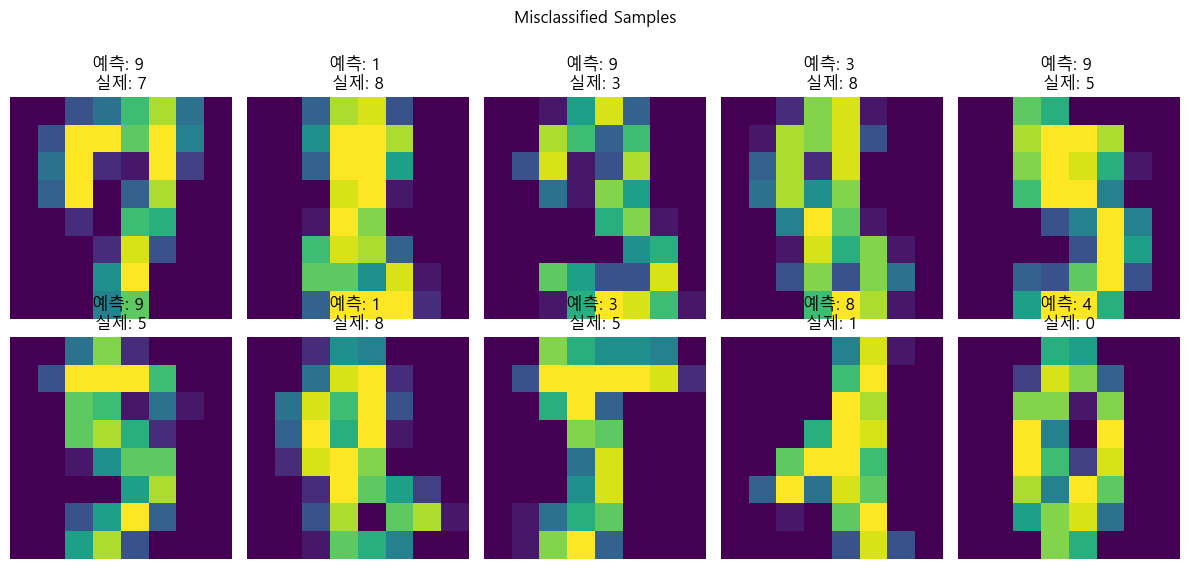

In [43]:
if len(incorrect_indices) > 0:
    print(f"\n{len(incorrect_indices)}개의 오분류된 샘플:")
    plt.figure(figsize=(12, 6))
    for plot_index, wrong_index in enumerate(incorrect_indices[:10][0]): # 최대 10개만 시각화
        if plot_index == 10:
            break
        plt.subplot(2,5,plot_index+1)
        plt.imshow(X_test[wrong_index].reshape(8,8))
        plt.title(f'예측: {pred_test[wrong_index]} \n실제: {y_test[wrong_index]}')
        plt.axis('off')
    plt.suptitle('Misclassified Samples')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("\n모든 샘플이 올바르게 분류되었습니다!")

# 2. DecisionTree

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


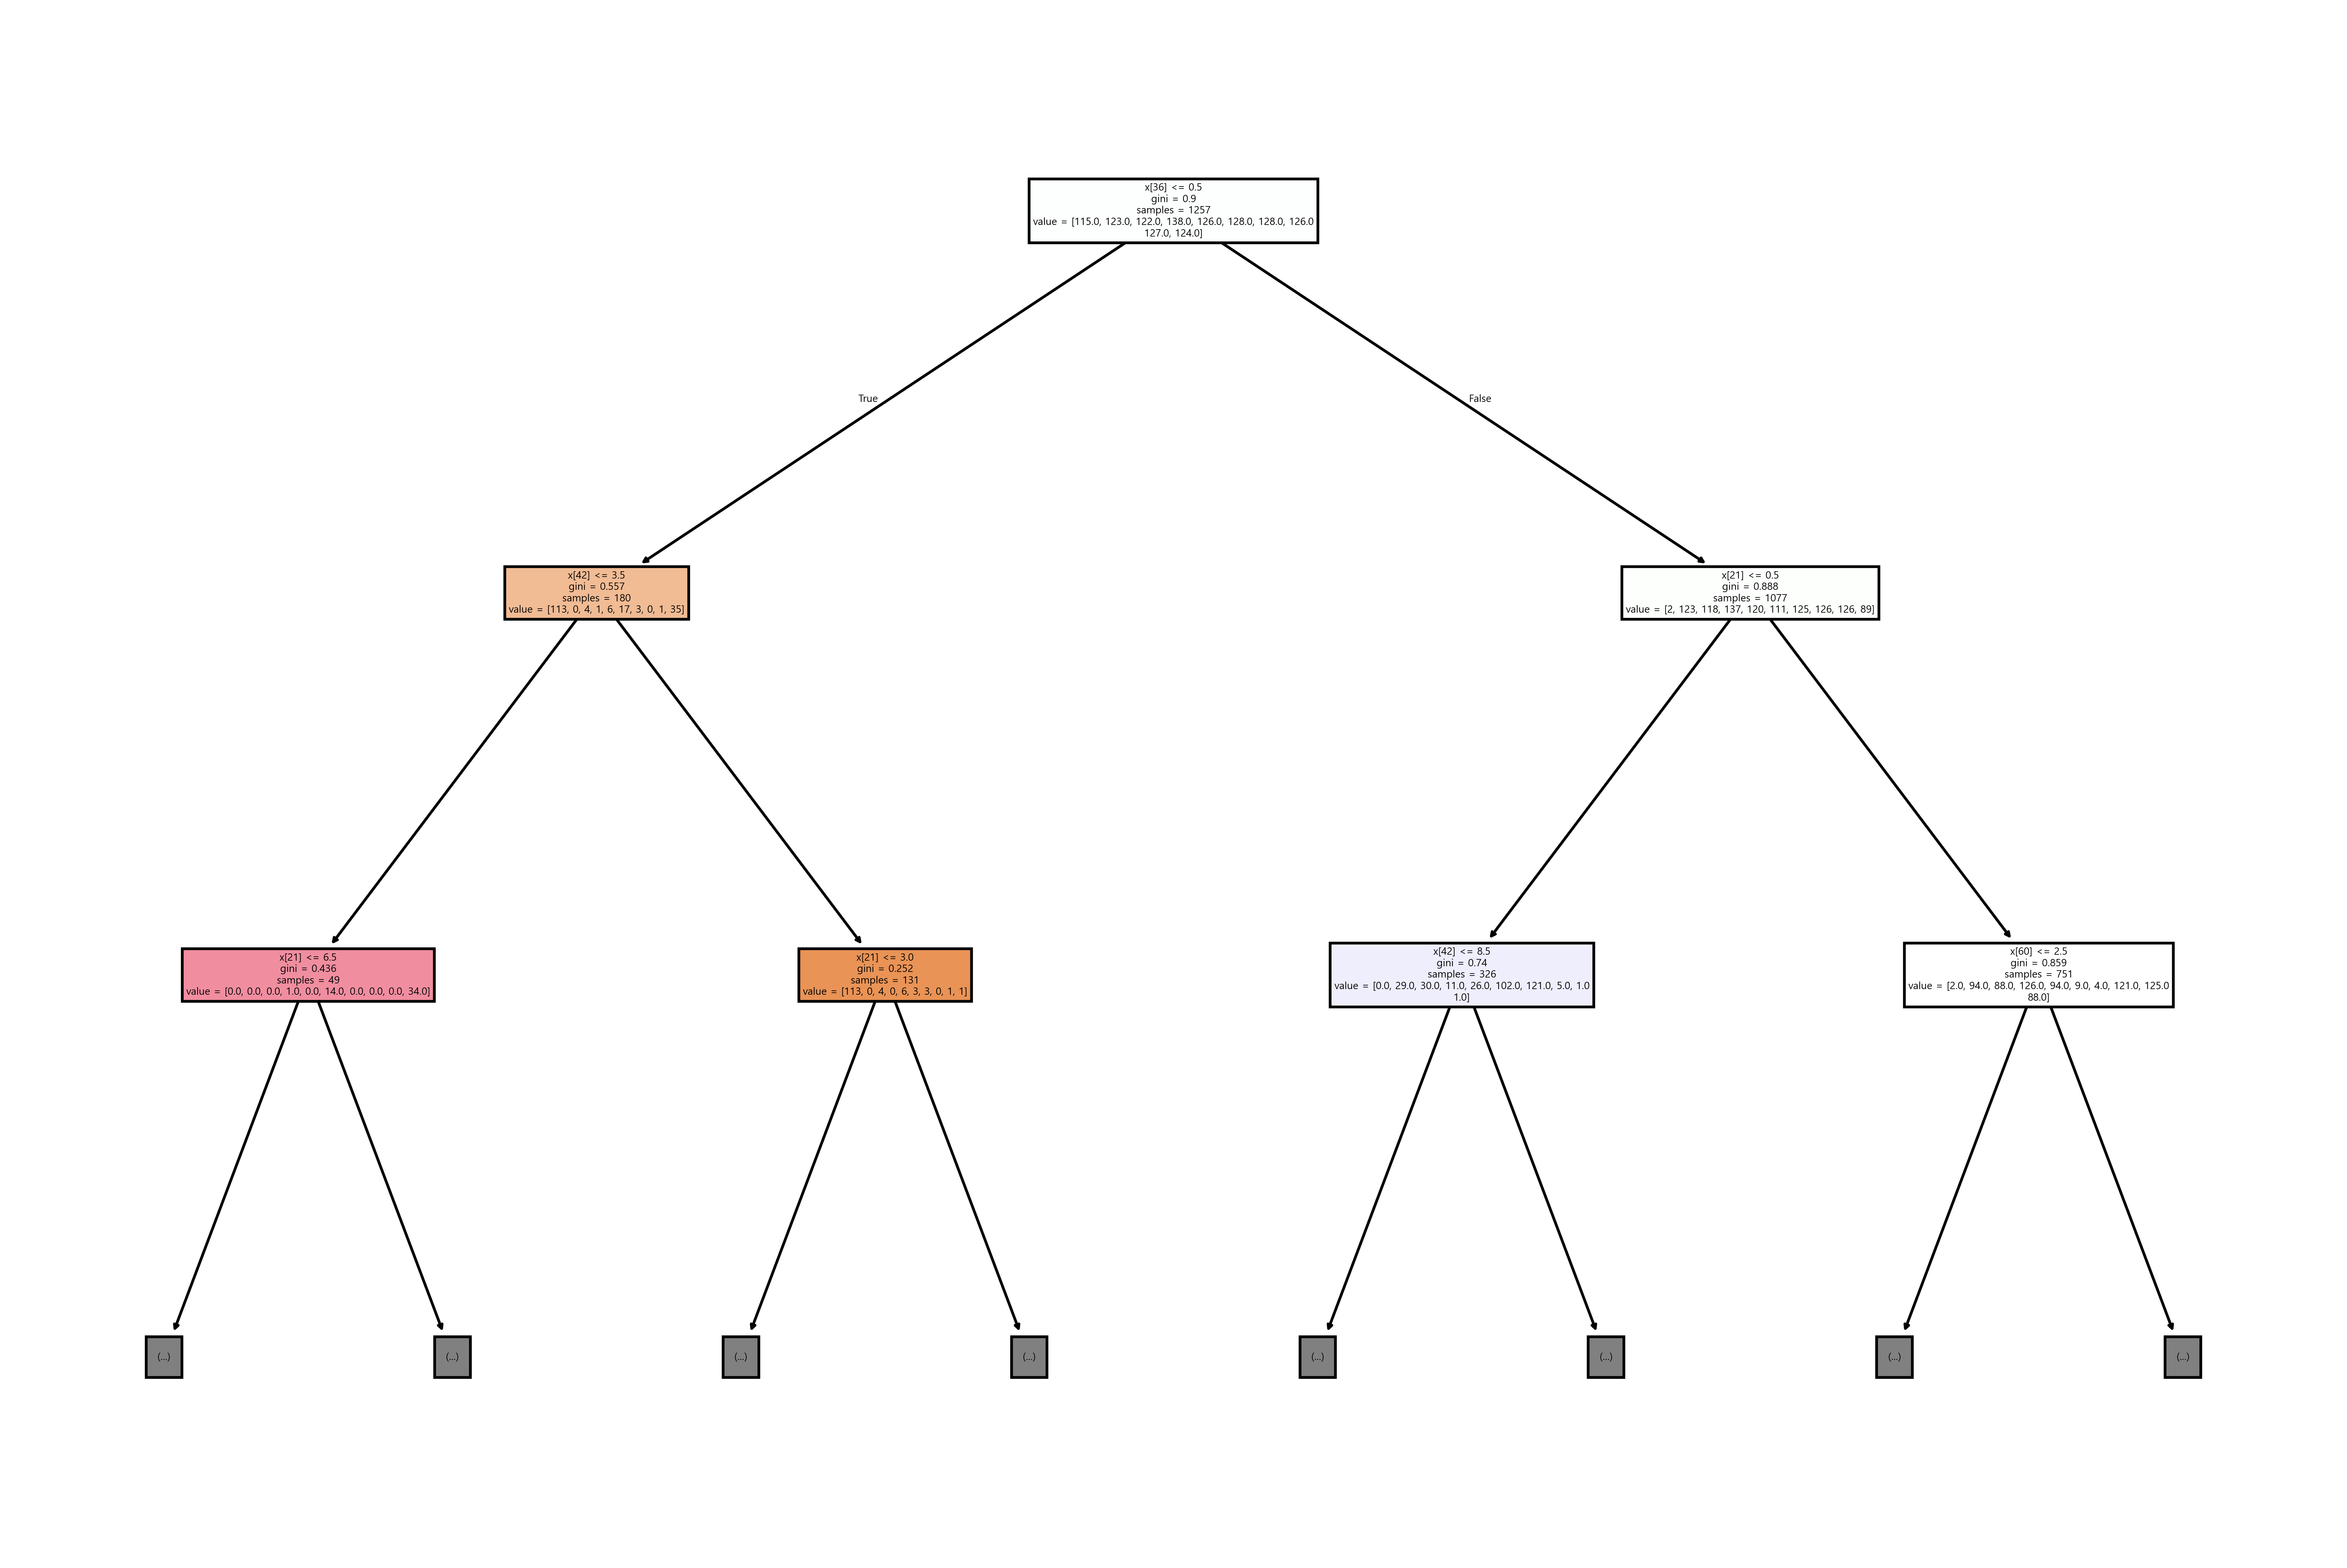

In [49]:
plt.figure(figsize=(15,10), dpi=600)
plot_tree(dt_clf, max_depth=2, filled=True)
plt.show()

In [55]:
print(dt_clf.score(X_train, y_train))
print(dt_clf.score(X_test, y_test))

1.0
0.8574074074074074


In [52]:
digits['data'][100].shape

(64,)

In [53]:
digits['data'][100].reshape(1, -1).shape

(1, 64)

In [56]:
digits.target[100] # 정답

np.int64(4)

In [58]:
# 이미지 하나 예측
img = digits.data[100].reshape(1,-1)
pred = dt_clf.predict(img)
pred # 정답과 같음

array([4])

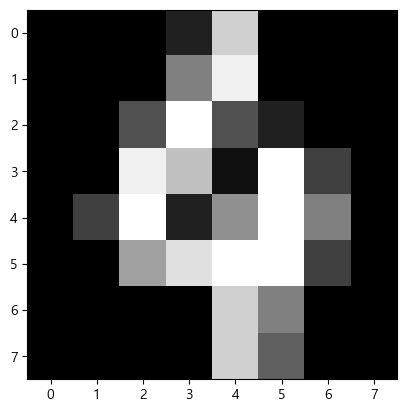

In [64]:
# 예측한 이미지
plt.imshow(img.reshape(8,8), cmap=plt.cm.gray)
plt.show()

# "실습" KNN 으로 분류

In [67]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=.3, random_state=42)
X_train.shape, y_train.shape

((1257, 64), (1257,))

In [76]:
np.unique(digits.target)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [68]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [73]:
print(knn.score(X_train, y_train)) # 학습데이터 기준의 점수
print(knn.score(X_test, y_test)) # 테스트 데이터 점수

0.9896579156722355
0.9925925925925926


# 앙상블

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

In [111]:
# Wine data (simple)
wine = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/wine.csv')

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

X_train, X_test, y_train, y_test = \
    train_test_split(data, target, test_size=0.2, random_state=42)

In [112]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print(rf.score(X_train, y_train), rf.score(X_test, y_test)) # 과적합

0.996921300750433 0.8884615384615384


In [113]:
rf.feature_importances_ # 두번째 컬럼 데이터가 중요도가 높다는 것을 인지함

array([0.22793495, 0.50517294, 0.2668921 ])

In [114]:
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=50)
rf.fit(X_train, y_train)
print(rf.oob_score_)

0.8951318068116221


In [115]:
%%time
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

params = {
    'n_estimators': [100],
    'max_depth': [6,8,10,12],
    'min_samples_leaf': [8,12,18],
    'min_samples_split': [8, 16, 20]
}

rf_clf = RandomForestClassifier(random_state=50, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

CPU times: total: 469 ms
Wall time: 5.86 s


,estimator,RandomForestC...ndom_state=50)
,param_grid,"{'max_depth': [6, 8, ...], 'min_samples_leaf': [8, 12, ...], 'min_samples_split': [8, 16, ...], 'n_estimators': [100]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [116]:
print(grid_cv.best_params_)

{'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}


In [117]:
print(grid_cv.best_score_)

0.872425691648443


In [118]:
rf_clf = RandomForestClassifier.fit(X_train, y_train)

AttributeError: 'numpy.ndarray' object has no attribute '_validate_params'

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ft_importances = pd.Series(rf_clf.feature_importances_, index=['alcohol','sugar','pH'])
ft_top20 = ft_importances.sort_values(ascending=False)[:20] #top 20

plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 20')
sns.barplot(x=ft_top20, y=ft_top20.index)
plt.show()


AttributeError: 'GridSearchCV' object has no attribute 'feature_importances_'

In [119]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_jobs=-1, random_state=50)
score2 = cross_validate(et, X_train, y_train, return_train_score=True, n_jobs=-1)
print(np.mean(score2['train_score']), np.mean(score2['test_score']))

0.9974503966084433 0.8860909158214259


In [120]:
et.fit(X_train, y_train)
print(et.feature_importances_)

[0.19494194 0.52232625 0.28273181]


### ADA

In [121]:
from sklearn.ensemble import AdaBoostClassifier

clf = AdaBoostClassifier(n_estimators=100, random_state=50)
clf.fit(X_train, y_train)
pred_ada = clf.predict(X_test)

In [122]:
print(classification_report(y_test, pred_ada)) # forest보다 조금 낮음

              precision    recall  f1-score   support

         0.0       0.72      0.70      0.71       341
         1.0       0.89      0.90      0.90       959

    accuracy                           0.85      1300
   macro avg       0.80      0.80      0.80      1300
weighted avg       0.85      0.85      0.85      1300



### GBM

In [123]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=50)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
print(classification_report(y_test, pred_gb))

              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74       341
         1.0       0.91      0.92      0.91       959

    accuracy                           0.87      1300
   macro avg       0.83      0.82      0.83      1300
weighted avg       0.87      0.87      0.87      1300



In [124]:
gb2 = GradientBoostingClassifier(random_state=50)
score3 = cross_validate(gb2, X_train, y_train, return_train_score=True, n_jobs=-1)
print(np.mean(score3['train_score']), np.mean(score3['test_score']))

0.8881086892152563 0.8718505219515806


In [125]:
gb2.fit(X_train, y_train)
gb2.feature_importances_

array([0.11908999, 0.74879405, 0.13211596])

### 히스토그램 기반 부스팅

In [126]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=50)
scores = cross_validate(hgb, X_train, y_train, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9321723946453317 0.8801241948619236


In [127]:
hgb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [ ]:
# pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
    --------------------------------------- 2.9/150.0 MB 18.1 MB/s eta 0:00:09
   --- ------------------------------------ 14.2/150.0 MB 37.6 MB/s eta 0:00:04
   ------ --------------------------------- 24.9/150.0 MB 43.0 MB/s eta 0:00:03
   -------- ------------------------------- 32.2/150.0 MB 44.0 MB/s eta 0:00:03
   ----------- ---------------------------- 44.8/150.0 MB 44.8 MB/s eta 0:00:03
   --------------- ------------------------ 58.5/150.0 MB 47.8 MB/s eta 0:00:02
   ------------------ --------------------- 70.3/150.0 MB 48.9 MB/s eta 0:00:02
   -------------------- ------------------- 76.8/150.0 MB 47.1 MB/s eta 0:00:02
   ----------------------- ---------------- 87.8/150.0 MB 47.4 MB/s eta 0:00:02
   -------------------------- ------------ 101.4/150.0 MB 49.0 MB/s eta 0:00:01
   ------------------------------ -------- 115.6/150.0 MB 51.0 MB/s eta 0:00:01
   ------------------------------- ------- 122.2/1

### XGBoost

In [130]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=50)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [131]:
scores = cross_validate(xgb, X_train, y_train, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9567059184812372 0.8783915747390243


In [132]:
pred = xgb.predict(X_test)
accuracy_score(pred, y_test)

0.8746153846153846

### LGBM

In [134]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=50)
scores = cross_validate(lgbm, X_train, y_train, return_train_score=True, n_jobs=-1)
lgbm.fit(X_train, y_train)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.935828414851749 0.8801251203079884


In [135]:
pred = lgbm.predict(X_test)
accuracy_score(pred, y_test)

c:\Users\USER\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.8730769230769231

### Catboost

In [ ]:
# pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   - -------------------------------------- 4.2/102.4 MB 42.9 MB/s eta 0:00:03
   -- ------------------------------------- 5.2/102.4 MB 13.1 MB/s eta 0:00:08
   ------ --------------------------------- 16.5/102.4 MB 27.8 MB/s eta 0:00:04
   ----------- ---------------------------- 30.4/102.4 MB 38.9 MB/s eta 0:00:02
   ------------- -------------------------- 35.4/102.4 MB 35.0 MB/s eta 0:00:02
   -------------- ------------------------- 37.0/102.4 MB 31.3 MB/s eta 0:00:03
   ----------------- ---------------------- 44.0/102.4 MB 30.7 MB/s eta 0:00:02
   ----------------- ---------------------- 44.3/102.4 MB 29.1 MB/s eta 0:00:02
   --------------------- ------------------ 54.8/102.4 MB 29.4 MB/s eta 0:00:02
   --------------------------- ------------ 69.2/102.4 MB 33.5 MB/s eta 0:00:01
   -------------------------------- ------- 82.8/102.4 MB 36.5 MB/s eta 0:00:01
   ----------------------------------- ---- 91.8/10

In [137]:
from catboost import CatBoostClassifier
cbc = CatBoostClassifier()
cbc.fit(X_train, y_train)

Learning rate set to 0.020824
0:	learn: 0.6702036	total: 134ms	remaining: 2m 14s
1:	learn: 0.6493385	total: 137ms	remaining: 1m 8s
2:	learn: 0.6311795	total: 140ms	remaining: 46.6s
3:	learn: 0.6125310	total: 143ms	remaining: 35.7s
4:	learn: 0.5966572	total: 146ms	remaining: 29.1s
5:	learn: 0.5801129	total: 149ms	remaining: 24.7s
6:	learn: 0.5678174	total: 152ms	remaining: 21.6s
7:	learn: 0.5543454	total: 155ms	remaining: 19.3s
8:	learn: 0.5408798	total: 158ms	remaining: 17.4s
9:	learn: 0.5288259	total: 162ms	remaining: 16s
10:	learn: 0.5167912	total: 165ms	remaining: 14.8s
11:	learn: 0.5051166	total: 168ms	remaining: 13.8s
12:	learn: 0.4949977	total: 171ms	remaining: 13s
13:	learn: 0.4845963	total: 174ms	remaining: 12.2s
14:	learn: 0.4746651	total: 177ms	remaining: 11.6s
15:	learn: 0.4652639	total: 180ms	remaining: 11.1s
16:	learn: 0.4570253	total: 183ms	remaining: 10.6s
17:	learn: 0.4496896	total: 186ms	remaining: 10.2s
18:	learn: 0.4430102	total: 189ms	remaining: 9.77s
19:	learn: 0.4

In [138]:
pred = cbc.predict(X_test)
print(accuracy_score(y_test, pred))

0.87


In [ ]:
scores = cross_validate(cbc, X_train, y_train, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score'])) # 학습데이터의 정확도는 떨어지지만 과적합이 조금 해소된 것을 확인할 수 있음

0.9114394110064064 0.8783925001850893


In [ ]:
# 해당내용은 혼자 공부하는 머신러닝+딥러닝 5-3.ipynb

# 파이썬 데이터 분석

## <Step1. 탐색> 데이터의 기초 정보 살펴보기

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = 'd/drinks.csv'
drinks = pd.read_csv(file_path) # read_csv 함수로 데이터를 Dataframe 형태로 불러옵니다.

In [142]:
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
 5   continent                     170 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ KB


In [144]:
drinks.head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
5,Antigua & Barbuda,102,128,45,4.9,NaN
6,Argentina,193,25,221,8.3,SA
7,Armenia,21,179,11,3.8,EU
8,Australia,261,72,212,10.4,OC
9,Austria,279,75,191,9.7,EU


In [145]:
drinks.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


## <Step2. 인사이트의 발견> : 탐색과 시각화

### [피처간의 상관관계 탐색]

In [ ]:
# 'beer_servings', 'wine_servings' 두 피처간의 상관계수를 계산합니다.
# pearson은 상관계수를 구하는 계산 방법 중 하나를 의미하며, 가장 널리 쓰이는 방법입니다.




In [148]:
# 피처간의 상관계수 행렬을 구합니다.

corr = drinks[['beer_servings','spirit_servings','wine_servings', 'total_litres_of_pure_alcohol']].corr()
print(corr)

                              beer_servings  spirit_servings  wine_servings  \
beer_servings                      1.000000         0.458819       0.527172   
spirit_servings                    0.458819         1.000000       0.194797   
wine_servings                      0.527172         0.194797       1.000000   
total_litres_of_pure_alcohol       0.835839         0.654968       0.667598   

                              total_litres_of_pure_alcohol  
beer_servings                                     0.835839  
spirit_servings                                   0.654968  
wine_servings                                     0.667598  
total_litres_of_pure_alcohol                      1.000000  


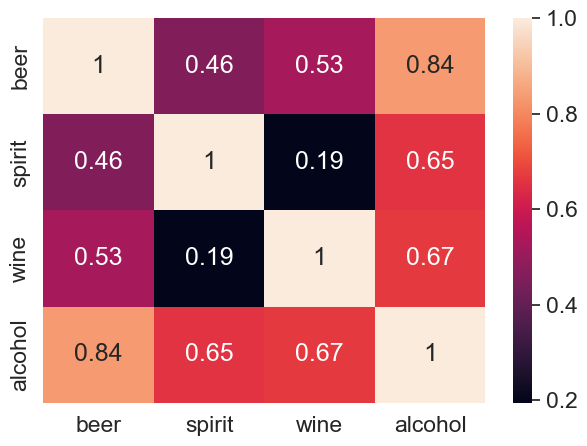

In [147]:
import seaborn as sns

# corr 행렬 히트맵을 시각화합니다.
cols_view = ['beer', 'spirit', 'wine', 'alcohol'] # 그래프 출력을 위한 cols 이름을 축약합니다.
sns.set(font_scale=1.5)
hm = sns.heatmap(corr.values, annot=True, yticklabels=cols_view, xticklabels=cols_view)
plt.tight_layout()
plt.show()

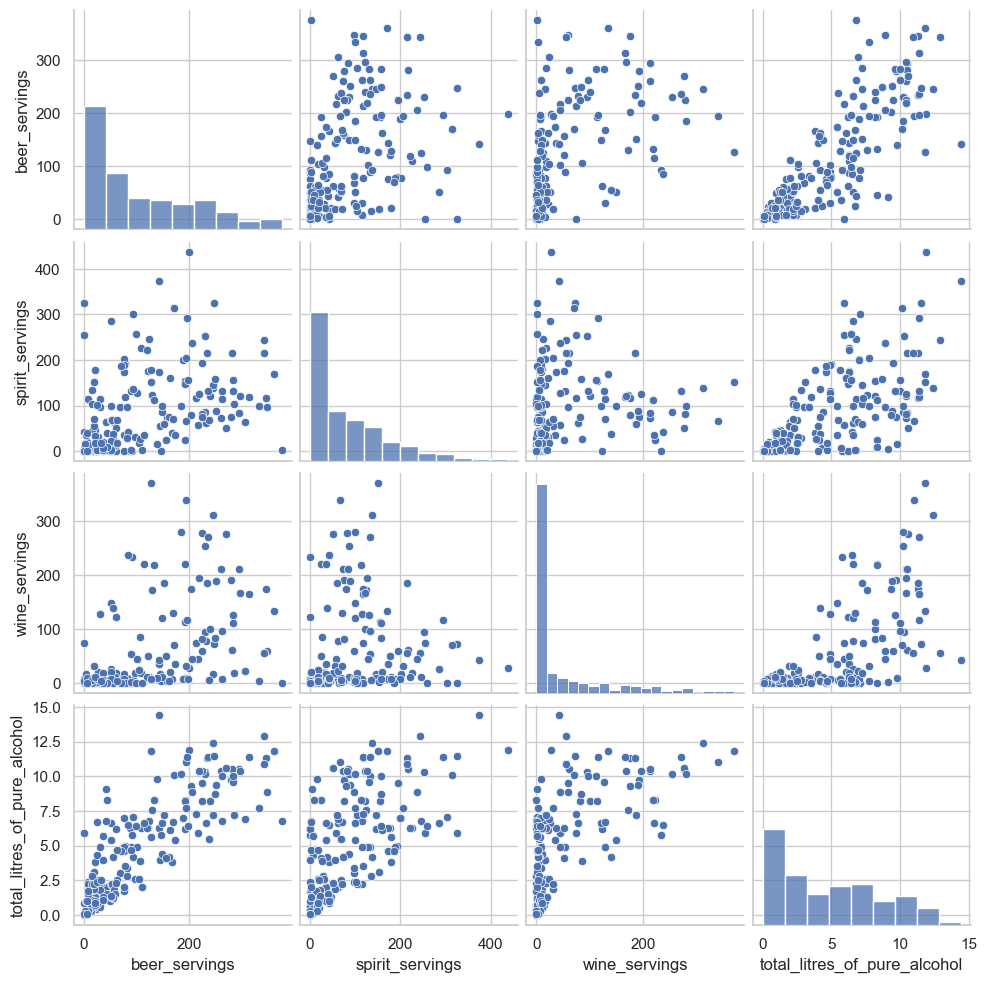

In [ ]:
# 시각화 라이브러리를 이용한 피처간의 scatter plot을 출력합니다.
sns.set(style='whitegrid', context='notebook')
sns.pairplot(drinks[['beer_servings','spirit_servings','wine_servings', 'total_litres_of_pure_alcohol']])
plt.show()

## <Step3. 탐색적 분석> : 스무고개로 분석하는 개념적 탐색

### [결측 데이터 전처리]

In [156]:
drinks.isna().sum(), drinks.dtypes

(country                          0
 beer_servings                    0
 spirit_servings                  0
 wine_servings                    0
 total_litres_of_pure_alcohol     0
 continent                       23
 dtype: int64,
 country                          object
 beer_servings                     int64
 spirit_servings                   int64
 wine_servings                     int64
 total_litres_of_pure_alcohol    float64
 continent                        object
 dtype: object)

In [ ]:
# 결측데이터를 처리합니다 : 기타 대륙으로 통합 -> 'OT'
drinks['continent'] = drinks.continent.fillna('OT')

In [177]:
drinks.isna().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

In [178]:
drinks.head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
5,Antigua & Barbuda,102,128,45,4.9,OT
6,Argentina,193,25,221,8.3,SA
7,Armenia,21,179,11,3.8,EU
8,Australia,261,72,212,10.4,OC
9,Austria,279,75,191,9.7,EU


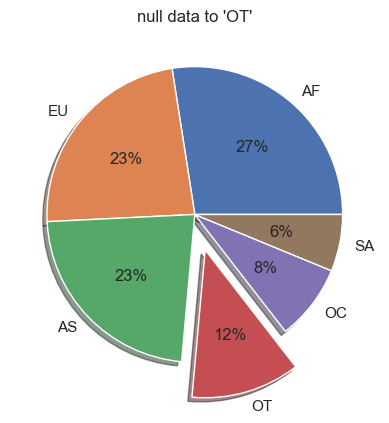

In [ ]:
# 파이차트 시각화
labels = drinks['continent'].value_counts().index #.tolist()
fracs1 = drinks['continent'].value_counts().values #.tolist()
explode = (0, 0, 0, 0.25, 0, 0)

plt.pie(fracs1, explode=explode, labels=labels, autopct='%.0f%%', shadow=True)
plt.title('null data to \'OT\'')
plt.show()

In [193]:
# 대륙별 spirit_servings의 평균, 최소, 최대, 합계를 계산합니다.
result = drinks.groupby('continent').spirit_servings.agg(['mean','min','max','sum'])
result

,mean,min,max,sum
continent,,,,
AF,16.339623,0,152,866
AS,60.840909,0,326,2677
EU,132.555556,0,373,5965
OC,58.437500,0,254,935
OT,165.739130,68,438,3812
SA,114.750000,25,302,1377


In [194]:
# 전체 평균보다 많은 알코올을 섭취하는 대륙을 구합니다.

total_alcohol_mean = drinks.total_litres_of_pure_alcohol.mean()
continent_mean = drinks.groupby('continent')['total_litres_of_pure_alcohol'].mean()
continent_over_mean = continent_mean[ continent_mean > total_alcohol_mean]
print(continent_over_mean)

continent
EU    8.617778
OT    5.995652
SA    6.308333
Name: total_litres_of_pure_alcohol, dtype: float64


In [196]:
# 평균 beer_servings이 가장 높은 대륙을 구합니다.
beer_continent = drinks.groupby('continent')['beer_servings'].mean().idxmax()
print(beer_continent)

EU


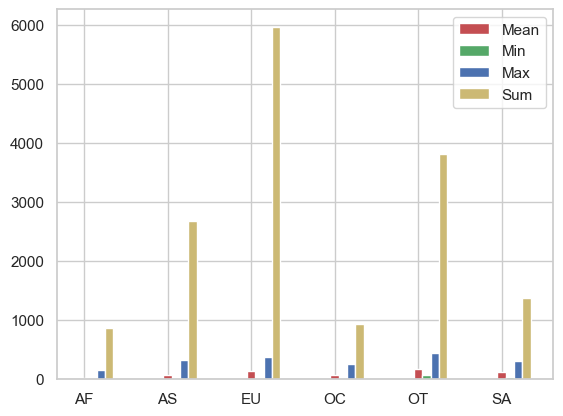

In [198]:
# 대륙별 spirit_servings의 평균, 최소, 최대, 합계를 시각화합니다.
n_groups = len(result.index)
means = result['mean'].tolist()
mins = result['min'].tolist()
maxs = result['max'].tolist()
sums = result['sum'].tolist()
 
index = np.arange(n_groups)
bar_width = 0.1
 
rects1 = plt.bar(index, means, bar_width,
                 color='r',
                 label='Mean')
 
rects2 = plt.bar(index + bar_width, mins, bar_width,
                 color='g',
                 label='Min')

rects3 = plt.bar(index + bar_width * 2, maxs, bar_width,
                 color='b',
                 label='Max')
 
rects3 = plt.bar(index + bar_width * 3, sums, bar_width,
                 color='y',
                 label='Sum')

plt.xticks(index, result.index.tolist())
plt.legend()
plt.show()